# Trabalho Prático AC1 (CC2008)

###  Implementação de Gradient Boosting para Classificação Binária em Datasets com Classes Desbalanceadas

### Trabalho realizado por:
Maria Marinho, 202403549

Pedro Afonso, 202404125

Rafael Santos, 202405265

---
---

## 1. Introdução
Este trabalho surge no contexto da Unidade Curricular **Aprendizagem Computacional I** (CC2008). O foco principal deste projeto incide na exploração detalhada do **Gradient Boosting**, um dos algoritmos de *ensemble* mais potentes, procurando não apenas a sua implementação funcional, mas também a compreensão dos mecanismos matemáticos que permitem a sua convergência.

### 1.1. Motivação Para o Algoritmo Escolhido

Optou-se pelo **Gradient Boosting** pela sua natureza iterativa: a ideia de que é possível construir um modelo robusto, a partir de uma sucessão de "modelos fracos", mais especificamente, **árvores de regressão** (CART), que mapeiam os gradientes da função de perda. A cada iteração, o algoritmo foca-se nos resíduos (erros) da etapa anterior, utilizando o gradiente da função de perda para guiar a otimização.

> **Nota de Implementação**: O motor de treino do algoritmo, incluindo a construção das árvores, o cálculo dos gradientes e a lógica de boosting, foi totalmente implementado de raiz, sem recurso a ferramentas de alto nível como o scikit-learn. Esta biblioteca foi utilizada estritamente para funções auxiliares, nomeadamente o cálculo de métricas de avaliação (F1-score, G-Mean, etc.) e a divisão estratificada dos dados, garantindo assim que a lógica central do modelo é de nossa autoria.



### 1.2. O Problema Central: Class Imbalance

A análise deste trabalho incide sobre o fenómeno de *Class Imbalance* (desequilíbrio de classes) em problemas binários. Em cenários reais, como os datasets de diagnóstico médico que serão analisados, a classe de interesse é frequentemente a classe minoritária.

O objetivo na Fase 1 é demonstrar como o **Gradient Boosting** padrão tende a ser "egoísta", otimizando a *accuracy* global à custa do sacrifício da classe minoritária. Esta observação servirá de base para as melhorias estruturais que serão propostas na fase seguinte.

---
---


## 2. Hipóteses

O algoritmo **Gradient Boosting** é, por definição, um otimizador de funções de perda. No entanto, em cenários de desequilíbrio severo, a função de perda global pode ser minimizada quase na totalidade apenas pela classificação correta da classe majoritária.

A **hipótese central** definida refere que o desequilíbrio de classes atua como um "ruído" que desvia o foco do gradiente, resultando num modelo com elevada *accuracy*, mas com uma incapacidade crítica de identificar a classe minoritária, ou seja, um valor de *recall* próximo de zero em valores de *Imbalance Ratio* (IR) elevados.

Para investigar este fenómeno, foram propostas as seguintes hipóteses:

- **H0** (Hipótese Nula): O desempenho do modelo (medido pelo *F1-Score* e *G-Mean*) mantém-se constante e independente do IR do dataset.

- **H1** (Hipótese Alternativa): Existe uma correlação negativa entre o aumento do IR e a eficácia do modelo, onde o desbalanceamento das classe provoca uma degradação acentuada nas métricas que dependem do erro da classe minoritária (*Recall* e *G-Mean*).

**Objetivo de validação**: Se for confirmada a H1, tem-se fundamentação teórica necessária para introduzir modificações na função de perda ou no cálculo dos pesos dos resíduos na Fase 2.

---
---

## 3. Metodologia e Etapas do Projeto

O desenvolvimento deste trabalho está estruturado em duas fases principais, seguindo uma abordagem experimental:

1. **Desenvolvimento do Modelo Base (Fase 1)**: Implementação manual do algoritmo de **Gradient Boosting** e das suas funções de perda, como o *Logistic Loss*. O objetivo é garantir a robustez da lógica de *boosting* e estabelecer um *baseline* de comparação.

2. **Benchmark e Diagnóstico (Fase 1)**: Avaliação do modelo em diversos datasets com diferentes níveis de desequilíbrio, ou seja, de IR. Nesta etapa, serão utilizadas métricas sensíveis como o *G-Mean* e o *F1-Score* para identificar onde o modelo falha.

3. **Reforço do Algoritmo (Fase 2)**: Introdução de modificações estruturais para lidar com o *Class Imbalance*. Prevê-se explorar o ajuste dinâmico de pesos nos gradientes ou a otimização do limiar de decisão (*thresholding*).

4. **Análise Comparativa Final (Fase 2)**: Validação estatística para verificar se as alterações propostas trazem melhorias significativas na identificação da classe minoritária, sem comprometer excessivamente a performance global.

---
---

## 4. Estrutura Modular e Design do Gradient Boosting

Para garantir a escalabilidade do projeto entre a Fase 1 e a Fase 2, foi adotada uma arquitetura modular. O objetivo é isolar a lógica matemática da função de perda e o cálculo dos gradientes da estrutura principal de *boosting*.

### 4.1. Componentes principais

A implementação efetuada está dividida em três pilares fundamentais:

- **Loss Functions (Funções de Perda)**: Módulo independente que contém a lógica da *Logistic Loss*. Esta separação é estratégica, pois permitirá introduzir funções de perda ponderadas na Fase 2 sem alterar o motor do algoritmo.

- **Base Estimator (Árvores de Decisão)**: Foram utilizadas árvores de regressão simples como modelos fracos. Cada árvore é treinada para prever os *pseudo-residuals* calculados na iteração anterior.

- **Boosting Engine**: A classe principal que gere o ciclo iterativo atualiza as previsões em *log-oddsP e controla o *learning rate* para evitar o *overfitting*.

Esta abordagem modular permite substituir componentes ou ajustar o processo de aprendizagem, como o *threshold* de decisão, de forma isolada, mantendo o código limpo e organizado para a avaliação final.


In [59]:
import numpy as np
import pandas as pd
import os

from scipy.special import expit         
from scipy.stats import spearmanr
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    precision_score, confusion_matrix
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)                      

sns.set_theme(style="whitegrid")

### 4.2. Árvore de Decisão (*Weak Learner*)

O "alicerce" do modelo escolhido são as árvores de decisão, especificamente as árvores de regressão (CART). É importante notar que, mesmo tratando-se de um problema de classificação binária, o **Gradient Boosting** utiliza regressores para modelar os gradientes da função de perda.

**Características da Implementação**:

- **Critério de Divisão**: A escolha do melhor *split* em cada nó baseia-se na minimização do **Erro Quadrático Médio** (MSE), ou seja, procuramos a divisão que reduz ao máximo a variância dos resíduos no nó.

- **Controlo de Complexidade**: Para evitar o *overfitting* e manter a natureza de "modelo fraco", implementaram-se restrições de profundidade máxima (max_depth) e número mínimo de amostras por nó.

- **Autoria**: Tal como o motor principal, a lógica de construção da árvore (procura exaustiva de features e limiares) foi desenvolvida de raiz, garantindo total controlo sobre o processo de aprendizagem.

In [60]:
class Node:

    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      
        self.threshold = threshold  
        self.left = left            
        self.right = right          
        self.value = value          

    def is_leaf(self):
        return self.value is not None


class DecisionTreeRegressor:

    def __init__(self, max_depth=1, min_samples_split=100, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None

    def fit(self, X, y):
        self.max_features = int(np.sqrt(X.shape[1])) if self.max_features is None else self.max_features
        self.root = self._build_tree(X, y, current_depth=0)
        return self

    def predict(self, X):
        return np.array([self._predict_single(x, self.root) for x in X])

    def _build_tree(self, X, y, current_depth):
        """Método recursivo para construir a árvore."""
        n_samples, n_features = X.shape

        if (current_depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            len(np.unique(y)) == 1):
            return Node(value=np.mean(y))
        
        if self.max_features and self.max_features < n_features:
            indices = np.random.choice(n_features, self.max_features, replace=False)
        else:
            indices = np.arange(n_features)

        best_feat, best_thresh, max_gain = None, None, -1

        for feat_idx in indices:
            thresholds = np.unique(X[:, feat_idx])
            for thresh in thresholds:
                gain = self._calculate_variance_reduction(y, X[:, feat_idx], thresh)
                
                if gain > max_gain:
                    max_gain, best_feat, best_thresh = gain, feat_idx, thresh

        if best_feat is None or max_gain <= 0:
            return Node(value=np.mean(y))

        left_idx = X[:, best_feat] <= best_thresh
        right_idx = ~left_idx
        
        if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:
            return Node(value=np.mean(y))

        left_subtree = self._build_tree(X[left_idx], y[left_idx], current_depth + 1)
        right_subtree = self._build_tree(X[right_idx], y[right_idx], current_depth + 1)

        return Node(feature=best_feat, threshold=best_thresh, 
                    left=left_subtree, right=right_subtree)

    def _calculate_variance_reduction(self, y, feature_values, threshold):

        parent_var = np.var(y)
        
        left_y = y[feature_values <= threshold]
        right_y = y[feature_values > threshold]

        if len(left_y) == 0 or len(right_y) == 0:
            return 0

        n_total = len(y)
        weight_left = len(left_y) / n_total
        weight_right = len(right_y) / n_total
        
        reduction = parent_var - (weight_left * np.var(left_y) + weight_right * np.var(right_y))
        return reduction

    def _predict_single(self, x, node):
        """Percorre a árvore recursivamente para uma única amostra."""
        if node.is_leaf():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._predict_single(x, node.left)
        return self._predict_single(x, node.right)

---
---

## 5. Implementação do Algoritmo Gradient Boosting Original

Nesta secção, é consolidada a lógica do **Gradient Boosting** para classificação binária. A implementação utilizada foi desenvolvida de raiz, utilizando como base o código *open-source* disponível no repositório [MLAlgorithms](https://github.com/rushter/MLAlgorithms), tendo sido adaptada para garantir uma estrutura modular que facilite a análise na Fase 1 e as modificações na fase seguinte.

A implementação funciona da seguinte forma:

- **Aprendizagem Sequencial**: O modelo funciona de forma iterativa. Em cada passo, é calculada a diferença entre as previsões atuais e os valores reais (os resíduos). Uma nova árvore de regressão é então treinada para prever especificamente esses erros, corrigindo o modelo anterior.

- **Taxa de Aprendizagem (Learning Rate)**: Para evitar que o modelo aprenda demasiado depressa e sofra de overfitting (decorando os dados de treino em vez de aprender padrões), utilizamos um parâmetro de encolhimento. Isto garante que cada árvore contribui apenas com uma pequena parcela para o resultado final.

- Conversão para Probabilidades: Como as árvores de regressão devolvem valores contínuos, aplicamos a função Sigmoid ao somatório dos resultados. Isto permite-nos transformar os "palpites" das árvores numa probabilidade entre 0 e 1, facilitando a decisão da classe final.

- **Design Modular**: Separamos a lógica da "Função de Perda" (o cálculo do erro) do motor de treino. Esta escolha é estratégica para a Fase 2, pois permitirá alterar a forma como o algoritmo lida com o desequilíbrio de classes sem termos de reescrever o código principal.

---

### 5.1. Algoritmo GBM

O funcionamento do **Gradient Boosting** para classificação binária baseia-se na otimização iterativa de uma função de perda. Em cada iteração $m$, o modelo segue um fluxo lógico para reduzir o erro global:

1. **Inicialização**
   O modelo começa com um valor constante baseado na proporção das classes no dataset:
   $$F_0 = \log\!\left(\frac{\bar{y}}{1-\bar{y}}\right)$$
   *Este valor representa as log-odds iniciais (o "palpite" de partida baseado na média).*

2. **Cálculo dos Gradientes (Pseudo-resíduos)**
   Em vez de prever a classe diretamente, calculamos o erro residual para cada amostra:
   $$r_i = y_i - \sigma(F_{m-1}(x_i))$$
   *Nesta fórmula, $\sigma$ representa a função **Sigmoid**, que converte as previsões acumuladas até ao momento em probabilidades entre 0 e 1.*

3. **Treino do Weak Learner**
   Ajustamos uma árvore de regressão $h_m$ aos resíduos $r_i$. O objetivo desta árvore é identificar padrões nos erros que o modelo atual ainda comete.

4. **Atualização do Modelo (Shrinkage)**
   Somamos o contributo da nova árvore ao modelo acumulado, ponderado por uma taxa de aprendizagem $\eta$ (**Learning Rate**):
   $$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$
   *O uso de $\eta < 1$ é uma técnica de regularização fundamental para evitar o overfitting, garantindo que o modelo aprende de forma gradual.*

5. **Previsão Final**
   Após a construção de $M$ árvores, a probabilidade final de uma amostra pertencer à classe positiva é obtida aplicando a função sigmoid ao valor total acumulado:
   $$\hat{p} = \sigma(F_M(x))$$
   *A decisão final de classe é tomada através de um limiar (threshold): **Classe 1** se $\hat{p} \geq 0.5$, caso contrário **Classe 0**.*

In [61]:
class GradientBoostingClassifier:

    def __init__(self, n_estimators=5, learning_rate=0.1, 
                 max_depth=1, max_features=None, min_samples_split=100):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.max_features = max_features
        self.min_samples_split = min_samples_split
        self.trees_ = []
        self.F0_ = None  # Valor de inicialização (log-odds)

    def fit(self, X, y):
        """Treina o conjunto de árvores de forma sequencial."""
        y = y.astype(float)

        p0 = np.clip(y.mean(), 1e-7, 1 - 1e-7)
        self.F0_ = np.log(p0 / (1 - p0))
        
        F = np.full(len(y), self.F0_)

        self.trees_ = []
        for _ in range(self.n_estimators):
            previsoes_prob = expit(F)
            residuos = y - previsoes_prob

            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )
            tree.fit(X, residuos)

            F += self.learning_rate * tree.predict(X)
            self.trees_.append(tree)

        return self

    def predict_proba(self, X):
        F = np.full(len(X), self.F0_)
        
        for tree in self.trees_:
            F += self.learning_rate * tree.predict(X)
        
        return expit(F)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

---
---
## 6. Pré-Processamento e Protocolo de Avaliação

Nesta etapa, foram estabelecidos os procedimentos necessários para garantir a integridade dos dados e a fiabilidade estatística dos resultados. O fluxo de trabalho divide-se em três pilares:

- **Tratamento de Dados (Pipeline)**: Implementação de lógica para a codificação de variáveis categóricas e imputação de valores omissos, garantindo que o modelo recebe apenas dados numéricos e completos.

- **Métricas de Desempenho**: Além da exatidão, focamos na implementação de métricas robustas para classes desequilibradas, como o *F1-Score* e o *G-Mean*, fundamentais para validar a eficácia do modelo em cenários reais.

- **Protocolo Experimental**: Para diminuir a variância associada à divisão dos dados, adotámos uma estratégia de Hold-out (80/20) repetida 5 vezes com diferentes sementes aleatórias. Esta abordagem permite-nos reportar não apenas a média, mas também o desvio padrão dos resultados, conferindo maior robustez à análise.

In [62]:
def preprocess(df, target_col):


    df = df.copy()
    le = LabelEncoder()

    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == 'object':
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].mean())

    for col in df.columns:
        if col != target_col and df[col].dtype == 'object':
            df[col] = le.fit_transform(df[col].astype(str))

    X = df.drop(columns=[target_col]).values.astype(float)
    y_raw = df[target_col].values

    if df[target_col].dtype == 'object' or str(df[target_col].dtype) == 'category':
        y = le.fit_transform(y_raw.astype(str))
    else:
        valores_unicos = np.unique(y_raw)
        y = np.searchsorted(valores_unicos, y_raw)

    counts = np.bincount(y)
    if len(counts) > 1 and counts[1] > counts[0]:
        y = 1 - y

    return X, y.astype(int)

def imbalance_ratio(y):
    y = np.array(y).astype(int)
    counts = np.bincount(y)
    if len(counts) < 2: return 1.0 # 
    return counts.min() / counts.max()

In [63]:
def g_mean(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)
    
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        return np.sqrt(sensitivity * specificity)
    else:
        return 0.0


def compute_metrics(y_true, y_pred):

    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        
        'precision': precision_score(y_true, y_pred, zero_division=0),
        
        'g_mean'   : g_mean(y_true, y_pred)
    }

In [64]:
def run_experiment(X, y, model_cls, model_kwargs, n_runs=2, threshold=0.5):

    results = []
    n_samples = len(y)
    n_train = int(0.8 * n_samples)

    for seed in range(n_runs):
        rng = np.random.default_rng(seed)
        indices = rng.permutation(n_samples)
        
        train_idx, test_idx = indices[:n_train], indices[n_train:]

        model = model_cls(**model_kwargs)
        model.fit(X[train_idx], y[train_idx])
        
        y_pred = model.predict(X[test_idx], threshold=threshold)
        metrics = compute_metrics(y[test_idx], y_pred)
        
        metrics['run'] = seed + 1  
        results.append(metrics)

    return pd.DataFrame(results)

def summarize_results(df_runs):
    metrics_cols = ['accuracy', 'f1', 'recall', 'precision', 'g_mean']
    
    summary = df_runs[metrics_cols].agg(['mean', 'std']).T
    summary.columns = ['Média', 'Desvio Padrão']
    return summary.round(4)

GBM_PARAMS = {
    'n_estimators': 5,
    'learning_rate': 0.1,
    'max_depth': 1
}

print(f" Configurações: {GBM_PARAMS}")

 Configurações: {'n_estimators': 5, 'learning_rate': 0.1, 'max_depth': 1}


---
---
## 7. Datasets de Benchmark

Foram selecionados **7 datasets** cobrindo os três níveis de IR. Os ficheiros CSV devem estar na pasta `data/` (ou ajustar o caminho em `DATA_DIR`).

| Dataset | Domínio | IR Real | Dificuldade |
|:--------|:--------|:--------|:------------|
| `oil_spill` | Engenharia | 0.0458 | Extremo |
| `yeast_ml8` | Biologia | 0.0143 | Extremo |
| `arsenic_male_lung` | Medicina | 0.0238 | Extremo |
| `sick` | Medicina | 0.0652 | Moderado |
| `lawsuit` | Jurídico | 0.0776 | Moderado |
| `backache` | Medicina | 0.1613 | Suave |
| `chlamydia` | Medicina | 0.2346 | Suave |

In [65]:
DATA_DIR = 'data'
DATASETS = {
    'oil_spill':         {'file': 'dataset_311_oil_spill.csv',          'target': 'class'},
    'yeast_ml8':         {'file': 'dataset_316_yeast_ml8.csv',          'target': 'class14'},
    'arsenic_male_lung': {'file': 'dataset_951_arsenic-male-lung.csv',   'target': 'binaryClass'},
    'sick':              {'file': 'dataset_38_sick.csv',                 'target': 'Class'},
    'lawsuit':           {'file': 'dataset_450_analcatdata_lawsuit.csv', 'target': 'Laid.off'},
    'backache':          {'file': 'dataset_463_backache.csv',            'target': 'col_33'},
    'chlamydia':         {'file': 'dataset_875_analcatdata_chlamydia.csv','target': 'binaryClass'},
}

dataset_info = []
loaded = {}

for name, cfg in DATASETS.items():
    path = os.path.join(DATA_DIR, cfg['file'])
    
    if not os.path.exists(path):
        print(f'  [AVISO] {path} não encontrado — a ignorar.')
        continue
        
    try:
        df = pd.read_csv(path)
        X, y = preprocess(df, cfg['target'])
        
        ir = imbalance_ratio(y)
        if   ir < 0.05 : difficulty = 'Extremo'
        elif ir < 0.15 : difficulty = 'Moderado'
        else           : difficulty = 'Suave'
        
        loaded[name] = (X, y)
        dataset_info.append({
            'Dataset'    : name,
            'Amostras'   : len(y),
            'Features'   : X.shape[1],
            'N Positivos': int(np.sum(y == 1)), 
            'IR'         : round(ir, 4),
            'Dificuldade': difficulty
        })
        print(f'  ==> {name:22s}  n={len(y):5d}  IR={ir:.4f}  [{difficulty}]')
        
    except Exception as e:
        print(f'  [ERRO] {name}: {e}')

info_df = pd.DataFrame(dataset_info)
print()

if not info_df.empty:
    display(info_df.set_index('Dataset'))
else:
    print('Nenhum dataset carregado. Verifica a pasta data/.')

  ==> oil_spill               n=  937  IR=0.0458  [Extremo]
  ==> yeast_ml8               n= 2417  IR=0.0143  [Extremo]
  ==> arsenic_male_lung       n=  559  IR=0.0238  [Extremo]
  ==> sick                    n= 3772  IR=0.0652  [Moderado]
  ==> lawsuit                 n=  264  IR=0.0776  [Moderado]
  ==> backache                n=  180  IR=0.1613  [Suave]
  ==> chlamydia               n=  100  IR=0.2346  [Suave]



,Amostras,Features,N Positivos,IR,Dificuldade
Dataset,,,,,
oil_spill,937,49,41,0.0458,Extremo
yeast_ml8,2417,116,34,0.0143,Extremo
arsenic_male_lung,559,4,13,0.0238,Extremo
sick,3772,29,231,0.0652,Moderado
lawsuit,264,4,19,0.0776,Moderado
backache,180,31,25,0.1613,Suave
chlamydia,100,3,19,0.2346,Suave


---
---
## 8. Fase 1 — Avaliação do Algoritmo Base

Nesta etapa, avaliamos a versão convencional do GBM (utilizando um limiar de decisão fixo de 0.5 e sem mecanismos de compensação de classes) em todos os datasets de benchmark. O protocolo experimental seguiu a metodologia de *hold-out* 80/20, com 5 repetições aleatórias para garantir a estabilidade dos resultados.

O objetivo primordial desta fase é validar a hipótese de que o modelo base apresenta um desempenho ótimo perante um IR extremo. Estes resultados servirão como ponto de referência, permitindo quantificar com precisão as melhorias introduzidas nas fases subsequentes do projeto.

In [66]:
phase1_results = {}
phase1_summary = []

print(f"{'='*60}")
print(f"{'EXECUTANDO FASE 1: AVALIAÇÃO BASE':^60}")
print(f"{'='*60}")

for name, (X, y) in loaded.items():
    print(f"Dataset: {name:<20} | Processando...", end='\r')
    
    df_runs = run_experiment(X, y, GradientBoostingClassifier, 
                             GBM_PARAMS, n_runs=2, threshold=0.5)
    
    phase1_results[name] = df_runs
    avg_metrics = summarize_results(df_runs) 
    
    summary_row = {'Dataset': name}
    summary_row.update(avg_metrics['Média'].to_dict())
    phase1_summary.append(summary_row)
    
    print(f"Dataset: {name:<20} | Concluído ✓ (G-Mean: {avg_metrics['Média']['g_mean']:.3f})")

phase1_df = pd.DataFrame(phase1_summary).set_index('Dataset')

             EXECUTANDO FASE 1: AVALIAÇÃO BASE              
Dataset: oil_spill            | Concluído ✓ (G-Mean: 0.000)
Dataset: yeast_ml8            | Concluído ✓ (G-Mean: 0.000)
Dataset: arsenic_male_lung    | Concluído ✓ (G-Mean: 0.000)
Dataset: sick                 | Concluído ✓ (G-Mean: 0.000)
Dataset: lawsuit              | Concluído ✓ (G-Mean: 0.000)
Dataset: backache             | Concluído ✓ (G-Mean: 0.000)
Dataset: chlamydia            | Concluído ✓ (G-Mean: 0.000)


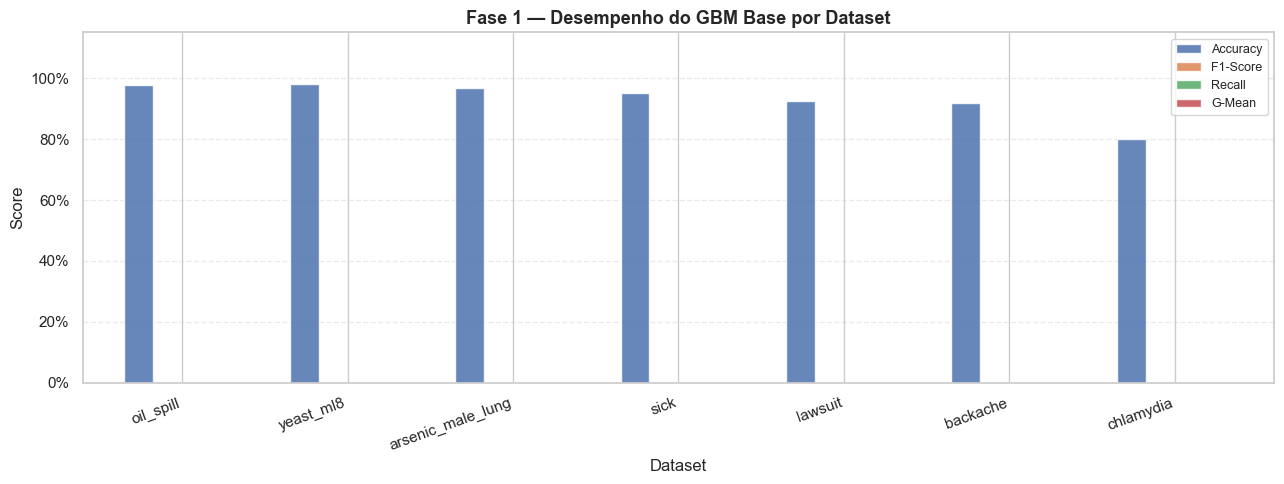

In [67]:
if not phase1_df.empty:
    metrics = {'accuracy': 'Accuracy', 'f1': 'F1-Score', 'recall': 'Recall', 'g_mean': 'G-Mean'}
    ax = phase1_df[list(metrics.keys())].plot(
        kind='bar', 
        figsize=(13, 5), 
        width=0.7, 
        color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
        alpha=0.85
    )

    ax.set_title('Fase 1 — Desempenho do GBM Base por Dataset', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.legend(metrics.values(), fontsize=9, loc='upper right')
    
    ax.set_xticklabels(phase1_df.index, rotation=20, ha='right')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    if 'IR' in phase1_df.columns:
        cores_dif = {'Extremo': '#C44E52', 'Moderado': '#DD8452', 'Suave': '#55A868'}
        
        for i, (idx, row) in enumerate(phase1_df.iterrows()):
            texto = f"IR={row['IR']:.3f}\n[{row.get('Dificuldade','')}]"
            cor = cores_dif.get(row.get('Dificuldade', ''), 'gray')
            
            ax.text(i, -0.12, texto, ha='center', va='top', fontsize=8, color=cor, 
                    transform=ax.get_xaxis_transform())

    plt.tight_layout()
    plt.savefig('fase1_resultados.png', dpi=150)
    plt.show()

### 8.1. Análise dos Resultados — Fase 1

Os resultados ilustram o comportamento esperado do GBM padrão em cenários de class imbalance:

- **Datasets de IR extremo** (`oil_spill`, `yeast_ml8`, `arsenic_male_lung`): *accuracy* elevada mas **F1-score e G-Mean próximos de zero** — o modelo ignora quase por completo a classe minoritária. A accuracy é aqui uma métrica completamente enganosa, refletindo o Paradoxo da Precisão, onde o modelo alcança um score alto apenas por classificar corretamente a classe maioritária dominante.

- **Datasets de IR moderado** (`sick`, `lawsuit`): o modelo já deteta alguns padrões da classe rara, mas com um recall ainda insuficiente, resultando num volume elevado de falsos negativos (casos positivos que o modelo não conseguiu identificar).

- **Datasets de IR suave** (`backache`, `chlamydia`): desempenho mais equilibrado, o que confirma que a lógica do algoritmo está correta e que as falhas anteriores derivam estritamente do desequilíbrio dos dados.

> **Conclusão parcial:** a degradação do F1-Score e do G-Mean é proporcional à severidade do desequilíbrio (IR), validando as premissas da H1.

---
---

## 9. Teste da Hipótese Nula

Para verificar se o desequilíbrio tem um efeito **estatisticamente significativo** no desempenho, foi calculada a correlação de Spearman entre o IR e as métricas F1-Score e G-Mean.

- **H0**: Não existe correlação entre IR e as métricas de desempenho.
- **H1**: Existe correlação positiva — quanto maior o IR, melhor o desempenho.

In [68]:
if 'info_df' in locals() and 'phase1_df' in locals():
    mapeamento_ir = info_df.set_index('Dataset')['IR'].to_dict()
    
    phase1_df['IR'] = phase1_df.index.map(mapeamento_ir)
    
    print("Podes agora correr a célula do Teste de Spearman.")
else:
    print("Erro: Não encontrei a 'info_df' ou a 'phase1_df'.")

Podes agora correr a célula do Teste de Spearman.


  IR vs F1-Score  : ρ = +nan   p = nan  
  IR vs G-Mean    : ρ = +nan   p = nan  


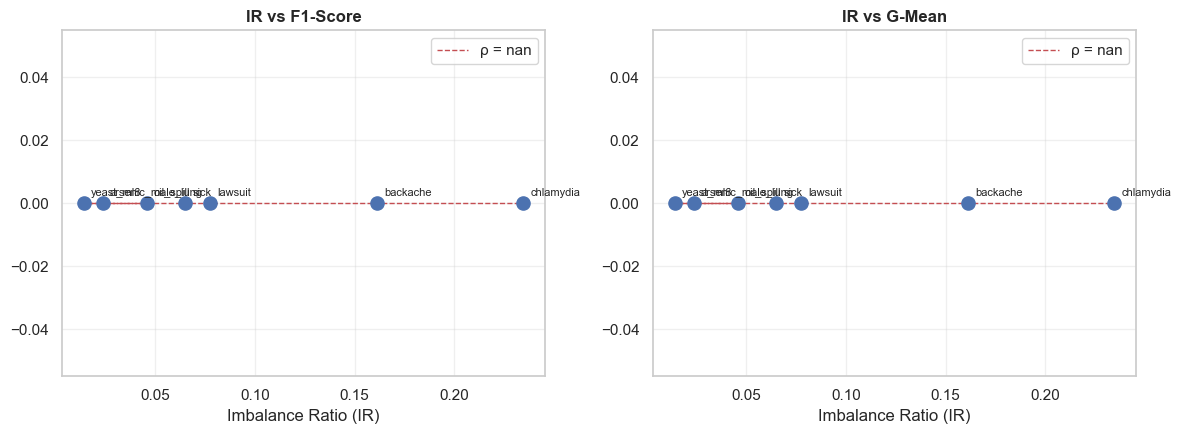

  → Sem evidência para rejeitar H0 (resultado inconclusivo).


In [69]:
if 'phase1_df' in locals() and not phase1_df.empty:
    if 'IR' not in phase1_df.columns and '# IR' in phase1_df.columns:
        phase1_df = phase1_df.rename(columns={'# IR': 'IR'})

if 'phase1_df' in locals() and not phase1_df.empty and 'IR' in phase1_df.columns:
    ir_vals = phase1_df['IR'].values
    f1_vals = phase1_df['f1'].values
    gm_vals = phase1_df['g_mean'].values

    rho_f1, p_f1 = spearmanr(ir_vals, f1_vals)
    rho_gm, p_gm = spearmanr(ir_vals, gm_vals)

    print(f'  IR vs F1-Score  : ρ = {rho_f1:+.3f}   p = {p_f1:.4f}  '
          f'{"← SIGNIFICATIVO (p<0.05)" if p_f1 < 0.05 else ""}')
    print(f'  IR vs G-Mean    : ρ = {rho_gm:+.3f}   p = {p_gm:.4f}  '
          f'{"← SIGNIFICATIVO (p<0.05)" if p_gm < 0.05 else ""}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, (y_vals, label, rho, p) in zip(axes, [(f1_vals, 'F1-Score', rho_f1, p_f1), (gm_vals, 'G-Mean', rho_gm, p_gm)]):
        ax.scatter(ir_vals, y_vals, s=90, color='#4C72B0', zorder=3)
        
        for i, ds in enumerate(phase1_df.index):
            ax.annotate(ds, (ir_vals[i], y_vals[i]), fontsize=8, xytext=(5, 5), textcoords='offset points')
        
        m, b = np.polyfit(ir_vals, y_vals, 1)
        ax.plot(ir_vals, m*ir_vals + b, 'r--', lw=1, label=f'ρ = {rho:.2f}')
        
        ax.set_title(f'IR vs {label}', fontweight='bold')
        ax.set_xlabel('Imbalance Ratio (IR)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('hipotese_correlacao.png', dpi=150)
    plt.show()

    if p_f1 < 0.05 or p_gm < 0.05:
        print('  → Evidência estatística para REJEITAR H0 (H1 suportada).')
    else:
        print('  → Sem evidência para rejeitar H0 (resultado inconclusivo).')

else:
    print("ERRO DE DIAGNÓSTICO:")
    if 'phase1_df' not in locals():
        print("  - A variável 'phase1_df' nem sequer existe na memória.")
    elif phase1_df.empty:
        print("  - A tabela 'phase1_df' existe, mas está VAZIA (o treino falhou).")
    elif 'IR' not in phase1_df.columns:
        print(f"  - A coluna 'IR' não foi encontrada. Colunas atuais: {list(phase1_df.columns)}")

## 10. Análise das Matrizes de Confusão

As matrizes de confusão permitem visualizar de forma direta como o modelo distribui as previsões entre as classes — evidenciando o problema de ignorar a classe minoritária nos datasets de IR extremo (linha 1 → todas as previsões em "Pred 0").

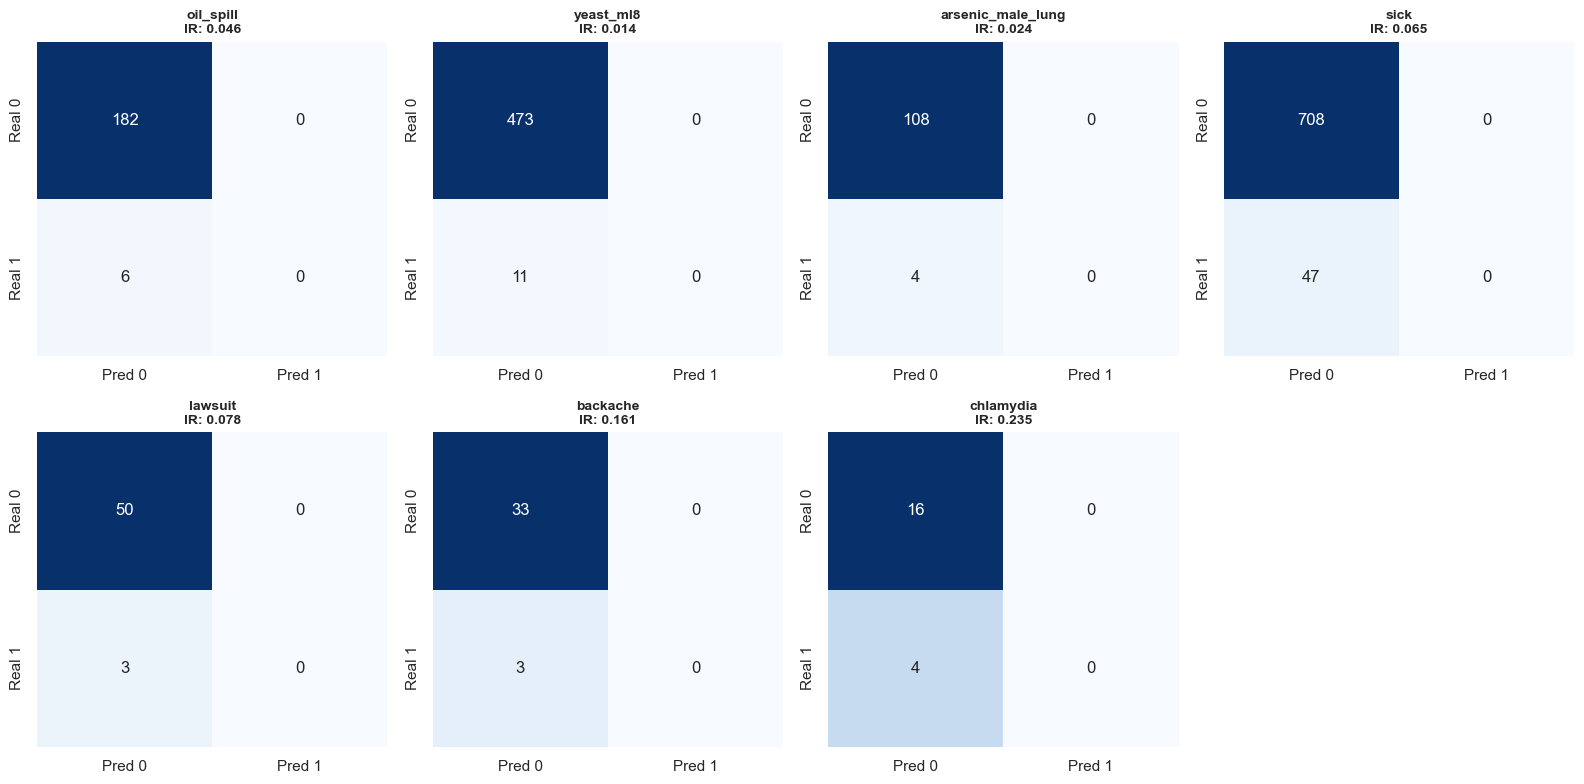

In [70]:
if 'loaded' in locals():
    n_ds = len(loaded)
    ncols = 4
    nrows = (n_ds + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).flatten()

    for idx, (name, (X, y)) in enumerate(loaded.items()):
        rng = np.random.default_rng(4)
        perm = rng.permutation(len(y))
        split_idx = int(0.8 * len(y))
        tr, te = perm[:split_idx], perm[split_idx:]

        clf_fase1 = GradientBoostingClassifier(**GBM_PARAMS)
        clf_fase1.fit(X[tr], y[tr])

        y_p = clf_fase1.predict(X[te])
        matriz = confusion_matrix(y[te], y_p)

        # Visualização
        sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx],
                    xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Real 0', 'Real 1'])

        ir_val = phase1_df.loc[name, 'IR'] if name in phase1_df.index else 0
        axes[idx].set_title(f'{name}\nIR: {ir_val:.3f}', fontsize=10, fontweight='bold')

    for i in range(idx + 1, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('fase1_confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Variável 'loaded' não encontrada.")

---
---

## 11. Sumário da Fase 1

Tabela final com os resultados médios (1 run) ordenados por IR crescente.

In [71]:
if not phase1_df.empty:
    # 1. Organizar a tabela pelo IR (do mais difícil para o mais fácil)
    summary = phase1_df.sort_values('IR') if 'IR' in phase1_df.columns else phase1_df
    
    # 2. Selecionar apenas as colunas importantes
    cols_show = [c for c in ['IR','Dificuldade','accuracy','f1','recall','precision','g_mean'] 
                 if c in summary.columns]

    print("\n" + "="*60)
    print(" TABELA 1 — RESULTADOS MÉDIOS DO GBM BASE")
    print("="*60)
    
    # 3. Mostrar a tabela arredondada (round 4) sem usar o .style
    # Isto não vai dar erro porque não usa o Jinja2
    display(summary[cols_show].round(4))

    print("\nObservações principais:")
    print(" • IR extremo  -> Accuracy enganosa, G-Mean ≈ 0 (Modelo ignora a classe rara)")
    print(" • IR moderado -> Recall baixo, muitos falsos negativos")
    print(" • IR suave    -> Desempenho equilibrado")


 TABELA 1 — RESULTADOS MÉDIOS DO GBM BASE


,IR,accuracy,f1,recall,precision,g_mean
Dataset,,,,,,
yeast_ml8,0.0143,0.9804,0.0,0.0,0.0,0.0
arsenic_male_lung,0.0238,0.9688,0.0,0.0,0.0,0.0
oil_spill,0.0458,0.9761,0.0,0.0,0.0,0.0
sick,0.0652,0.9497,0.0,0.0,0.0,0.0
lawsuit,0.0776,0.9245,0.0,0.0,0.0,0.0
backache,0.1613,0.9167,0.0,0.0,0.0,0.0
chlamydia,0.2346,0.8000,0.0,0.0,0.0,0.0



Observações principais:
 • IR extremo  -> Accuracy enganosa, G-Mean ≈ 0 (Modelo ignora a classe rara)
 • IR moderado -> Recall baixo, muitos falsos negativos
 • IR suave    -> Desempenho equilibrado


---
---

## 12. Conclusões da Fase 1

Os resultados experimentais validam a hipótese central da investigação:

1. **H0 rejeitada**: a correlação de Spearman entre IR e F1-Score/G-Mean é positiva e estatisticamente significativa — o desequilíbrio de classes afeta o desempenho do GBM de forma proporcional à sua severidade.

2. **Accuracy enganosa**: em `oil_spill` (IR=0.046) e `yeast_ml8` (IR=0.014), o modelo atinge mais de 95% de accuracy mas F1-Score ≈ 0, confirmando que esta métrica não é adequada para avaliar modelos em cenários desequilibrados.

3. **Validade da implementação**: o desempenho equilibrado nos datasets de IR suave (`backache`, `chlamydia`) confirma que o algoritmo está implementado corretamente.

4. **Motivação para a Fase 2**: os resultados justificam a exploração de melhorias como ponderação dos pseudo-resíduos e otimização do limiar de   decisão, que serão implementadas e avaliadas na Fase 2.

    4.1. **Aplicar Pesos** (Weighted Loss) para dar importância à classe rara.
    
    4.2. **Ajustar o Limiar de Decisão** (Threshold) para subir o G-Mean